In [6]:
import pandas as pd
import matplotlib.pyplot as plt



In [7]:
df = pd.read_csv("../outputs/metrics/test_0_frame_metrics.csv")

df.head()

,video_name,frame_number,processed_frame,timestamp_sec,detected_people_count,unassigned_people,total_zones,occupied_zones,zone_1,zone_2,zone_3,zone_4,zone_5,zone_6,zone_7
0,test_0.mp4,6,1,0.2,9,0,4,2,0,0,1,1,NaN,NaN,NaN
1,test_0.mp4,12,2,0.4,9,1,4,2,0,0,1,1,NaN,NaN,NaN
2,test_0.mp4,18,3,0.6,8,0,4,2,0,0,1,1,NaN,NaN,NaN
3,test_0.mp4,24,4,0.8,9,0,4,2,0,0,1,1,NaN,NaN,NaN
4,test_0.mp4,30,5,1.0,11,0,4,2,0,0,1,1,NaN,NaN,NaN


In [8]:
df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

In [9]:
df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

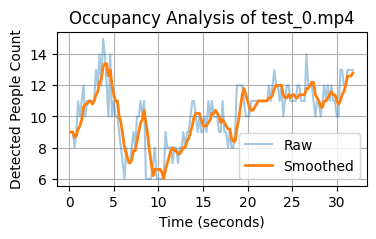

Average Occupancy : 10.18
Peak Occupancy    : 15
Minimum Occupancy : 6
Std Deviation     : 1.95


In [13]:
plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of test_0.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

2. ZONE UTILIZATION of test_0

     Zone  Utilization (%)
0  zone_1        67.295597
1  zone_2        25.786164
2  zone_3       100.000000
3  zone_4       100.000000


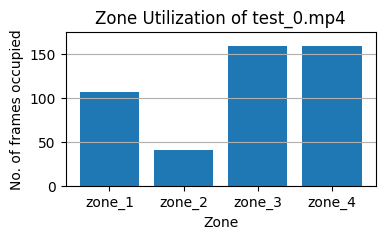

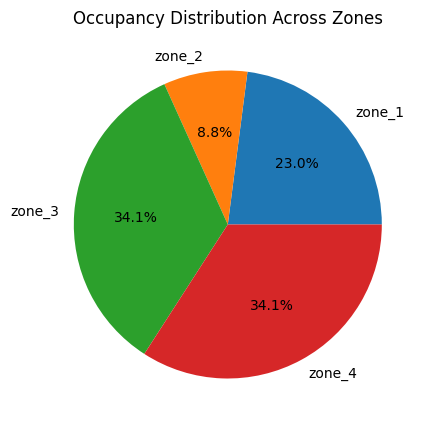

In [11]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of test_0.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones"
)

plt.show()

# video: test_1


In [14]:
df = pd.read_csv("../outputs/metrics/test_1_frame_metrics.csv")

df.head()

,video_name,frame_number,processed_frame,timestamp_sec,detected_people_count,unassigned_people,total_zones,occupied_zones,zone_1,zone_2,zone_3,zone_4,zone_5,zone_6,zone_7
0,test_1.mp4,6,1,0.2,10,3,5,3,1,1,0,1,0,NaN,NaN
1,test_1.mp4,12,2,0.4,7,2,5,2,0,1,0,1,0,NaN,NaN
2,test_1.mp4,18,3,0.6,8,2,5,3,1,1,0,1,0,NaN,NaN
3,test_1.mp4,24,4,0.8,8,1,5,3,1,1,0,1,0,NaN,NaN
4,test_1.mp4,30,5,1.0,9,2,5,3,1,1,0,1,0,NaN,NaN


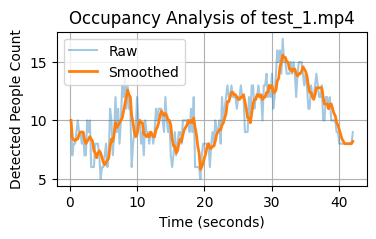

Average Occupancy : 10.26
Peak Occupancy    : 17
Minimum Occupancy : 5
Std Deviation     : 2.55


In [17]:
df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of test_1.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

     Zone  Utilization (%)
0  zone_1        90.000000
1  zone_2        25.238095
2  zone_3         7.142857
3  zone_4       100.000000
4  zone_5        64.761905


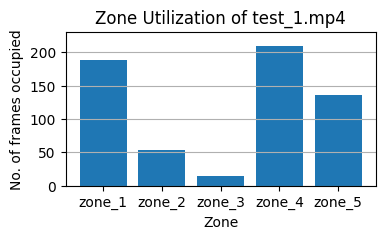

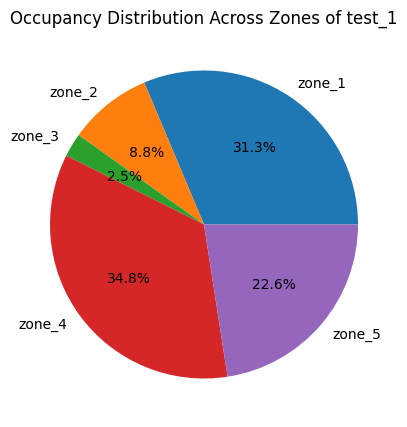

In [19]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    "zone_5",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of test_1.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of test_1"
)

plt.show()

# test_2

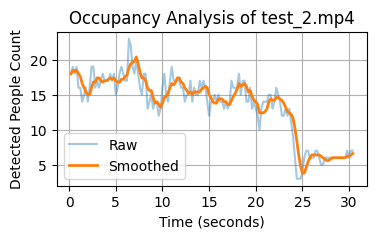

Average Occupancy : 13.49
Peak Occupancy    : 23
Minimum Occupancy : 3
Std Deviation     : 4.50


In [20]:
df = pd.read_csv("../outputs/metrics/test_2_frame_metrics.csv")

# df.head()

df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of test_2.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

     Zone  Utilization (%)
0  zone_1        97.368421
1  zone_2        98.684211
2  zone_3        75.657895
3  zone_4       100.000000


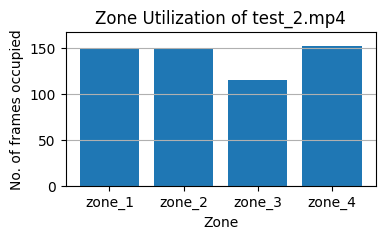

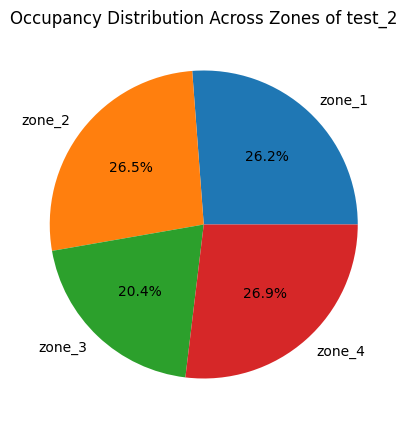

In [21]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    # "zone_5",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of test_2.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of test_2"
)

plt.show()

# market_0

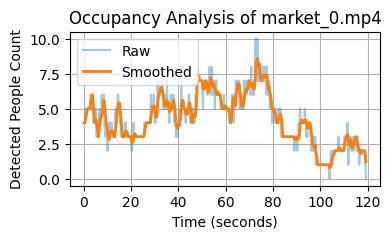

Average Occupancy : 4.28
Peak Occupancy    : 10
Minimum Occupancy : 0
Std Deviation     : 1.84


In [22]:
df = pd.read_csv("../outputs/metrics/market_0_frame_metrics.csv")

# df.head()

df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of market_0.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

     Zone  Utilization (%)
0  zone_1        81.711409
1  zone_2        90.100671
2  zone_3         3.859060
3  zone_4         1.845638
4  zone_5         0.000000
5  zone_6        10.570470


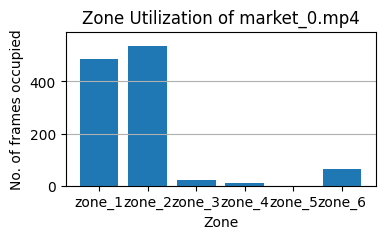

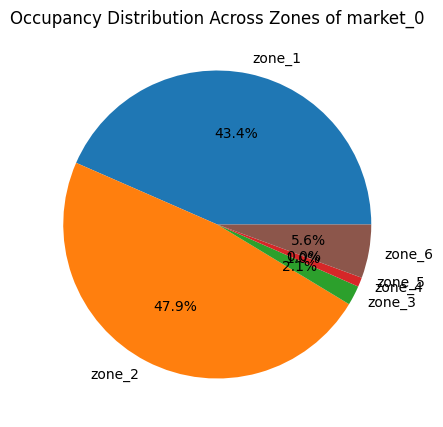

In [24]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    "zone_5",
    "zone_6",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of market_0.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of market_0"
)

plt.show()

# market_1

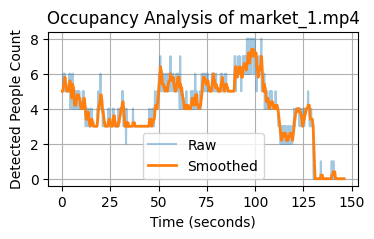

Average Occupancy : 3.92
Peak Occupancy    : 8
Minimum Occupancy : 0
Std Deviation     : 1.83


In [25]:
df = pd.read_csv("../outputs/metrics/market_1_frame_metrics.csv")

# df.head()

df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of market_1.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

     Zone  Utilization (%)
0  zone_1        82.739726
1  zone_2        87.260274
2  zone_3        54.931507
3  zone_4        88.356164
4  zone_5         2.465753


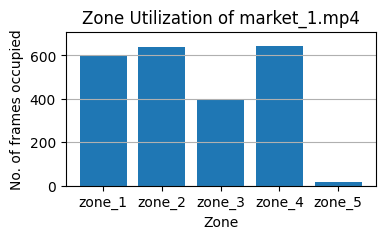

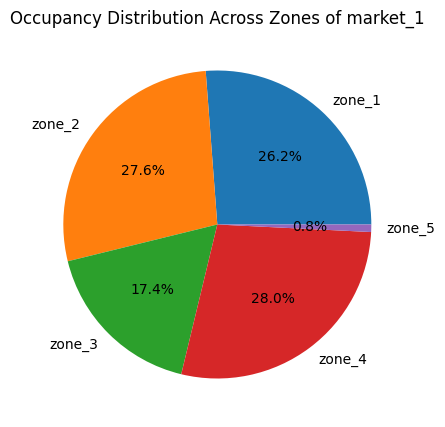

In [26]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    "zone_5",
    # "zone_6",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of market_1.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of market_1"
)

plt.show()

# market_2

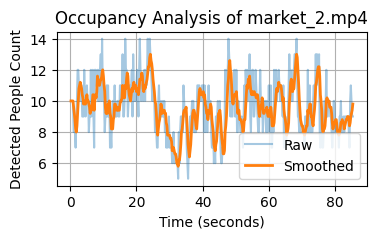

Average Occupancy : 9.57
Peak Occupancy    : 14
Minimum Occupancy : 5
Std Deviation     : 1.77


In [27]:
df = pd.read_csv("../outputs/metrics/market_2_frame_metrics.csv")

# df.head()

df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of market_2.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

     Zone  Utilization (%)
0  zone_1        41.217799
1  zone_2        87.119438
2  zone_3        99.297424
3  zone_4        91.100703
4  zone_5        89.695550
5  zone_6         0.000000


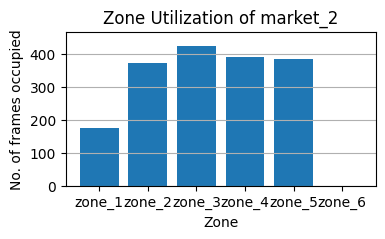

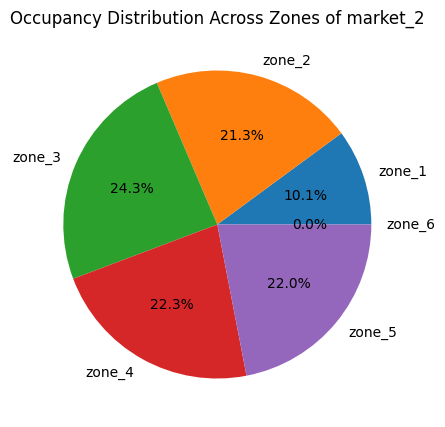

In [28]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    "zone_5",
    "zone_6",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of market_2")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of market_2"
)

plt.show()

# office_0


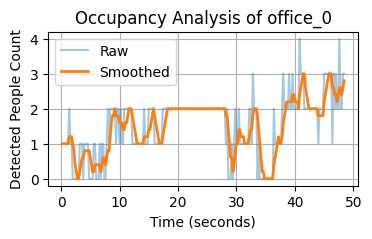

Average Occupancy : 1.52
Peak Occupancy    : 4
Minimum Occupancy : 0
Std Deviation     : 0.86


In [29]:
df = pd.read_csv("../outputs/metrics/office_0_frame_metrics.csv")

# df.head()

df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of office_0")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

     Zone  Utilization (%)
0  zone_1         4.958678
1  zone_2        28.512397
2  zone_3        52.066116
3  zone_4        11.570248


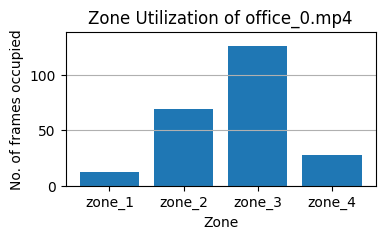

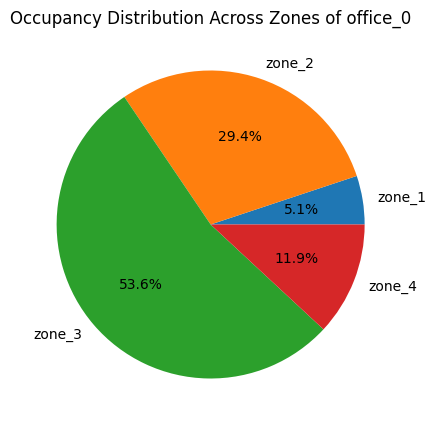

In [30]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    # "zone_5",
    # "zone_6",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of office_0.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of office_0"
)

plt.show()

# library_0

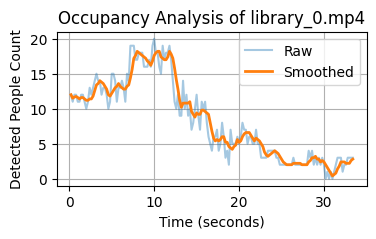

Average Occupancy : 8.35
Peak Occupancy    : 20
Minimum Occupancy : 0
Std Deviation     : 5.66


In [31]:
df = pd.read_csv("../outputs/metrics/library_0_frame_metrics.csv")

# df.head()

df["people_smooth"] = (
    df["detected_people_count"]
    .rolling(window=5, min_periods=1)
    .mean()
)
# df.head()

df["time_sec"] = df["timestamp_sec"].astype(int)

occupancy_per_sec = (
    df.groupby("timestamp_sec")["detected_people_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(4,2))

plt.plot(
    df["timestamp_sec"],
    df["detected_people_count"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    df["timestamp_sec"],
    df["people_smooth"],
    linewidth=2,
    label="Smoothed"
)

plt.title("Occupancy Analysis of library_0.mp4")
plt.xlabel("Time (seconds)")
plt.ylabel("Detected People Count")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Occupancy : {df['detected_people_count'].mean():.2f}")

print(f"Peak Occupancy    : {df['detected_people_count'].max()}")

print(f"Minimum Occupancy : {df['detected_people_count'].min()}")

print(f"Std Deviation     : {df['detected_people_count'].std():.2f}")

In [ ]:
zone_columns = [
    "zone_1",
    "zone_2",
    "zone_3",
    "zone_4",
    # "zone_5",
    # "zone_6",
]

total_frames = len(df)

utilization = {}
zone_in_how_many_frames = {}
mx_utilized_frame = 0

for zone in zone_columns:

    occupied_frames = (df[zone] > 0).sum()

    utilization[zone] = (
        occupied_frames / total_frames
    ) * 100

    zone_in_how_many_frames[zone] = occupied_frames
    mx_utilized_frame = max(mx_utilized_frame, occupied_frames)

utilization_df = pd.DataFrame(
    utilization.items(),
    columns=["Zone", "Utilization (%)"]
)

print(utilization_df)
# print(mx_utilized_frame)

bar_df = pd.DataFrame(
    zone_in_how_many_frames.items(),
    columns = ["Zone", "No. of frames occupied"]
)

plt.figure(figsize=(4,2))

plt.bar(
    bar_df["Zone"],
    bar_df["No. of frames occupied"]
)

plt.title("Zone Utilization of market_0.mp4")
plt.xlabel("Zone")
plt.ylabel("No. of frames occupied")

plt.ylim(0,mx_utilized_frame*1.1)

plt.grid(axis="y")

plt.show()


plt.figure(figsize=(5,5))

plt.pie(
    utilization_df["Utilization (%)"],
    labels=utilization_df["Zone"],
    autopct="%1.1f%%"
)

plt.title(
    "Occupancy Distribution Across Zones of market_0"
)

plt.show()